# SETUP

In [1]:
# Import main libs
import os
# Avoid PyTensor compiling error on eCryptfs
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"
os.environ["PYTENSOR_FLAGS"] = "base_compiledir=/tmp/pytensor_cache"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from linearmodels import IV2SLS
import arviz as az
import preliz as pz
import pymc as pm
import xarray as xr
import pytensor.tensor as pt
az.style.use("preliz-doc")

In [2]:
# Define constants
PYMC_MODELS_PATH: str = "pymc_models"
Path(PYMC_MODELS_PATH).mkdir(parents=True, exist_ok=True)
SEED: int = 5
ROOT_PATH = Path.cwd()
print(f"Root path = {ROOT_PATH}")
N_CORES: int = os.cpu_count()
print(f"Number of cores = {N_CORES}")
N_CHAINS: int = int(N_CORES / 4)
print(f"Number of chains = {N_CHAINS}")

Root path = /home/gus-cunha/Projects/bayesian_causal_inference_study
Number of cores = 16
Number of chains = 4


# LINEAR REGRESSION

In [40]:
# Load data
df_lr = pd.read_csv(os.path.join(ROOT_PATH, "data", "causal_inference_in_python_linear_regression.csv"))
df_lr

,wage,educ,exper,married,credit_score1,credit_score2,credit_limit,default
0,950.0,11,16,1,500.0,518.0,3200.0,0
1,780.0,11,7,1,414.0,429.0,1700.0,0
2,1230.0,14,9,1,586.0,571.0,4200.0,0
3,1040.0,15,8,1,379.0,411.0,1500.0,0
4,1000.0,16,1,1,379.0,518.0,1800.0,0
...,...,...,...,...,...,...,...,...
49995,840.0,12,13,1,466.0,482.0,2400.0,0
49996,700.0,15,16,1,328.0,393.0,1100.0,0
49997,930.0,14,16,1,552.0,339.0,1700.0,0
49998,1550.0,17,7,1,569.0,536.0,3300.0,0


In [41]:
###############################
######### FREQUENTIST #########

# Define formula, where T = credit limit
formula = 'default ~ credit_limit + wage + credit_score1 + credit_score2'
# Fit model to data
model = smf.ols(formula, data=df_lr).fit()
# Inspect results
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.4037,0.009,46.939,0.000,0.387,0.421
credit_limit,3.063e-06,1.54e-06,1.987,0.047,4.16e-08,6.08e-06
wage,-8.822e-05,6.07e-06,-14.541,0.000,-0.000,-7.63e-05
credit_score1,-4.175e-05,1.83e-05,-2.278,0.023,-7.77e-05,-5.82e-06
credit_score2,-0.0003,1.52e-05,-20.055,0.000,-0.000,-0.000


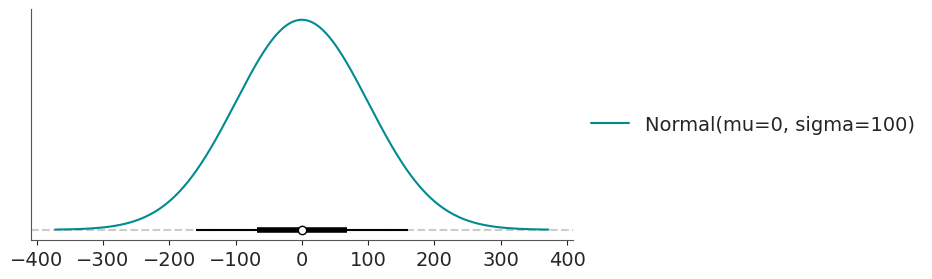

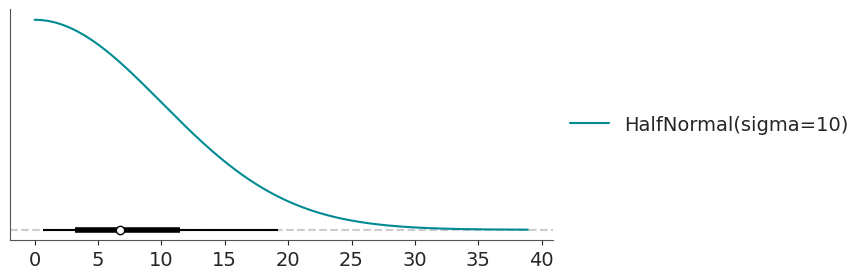

In [42]:
##########################
######### PRIORS #########

pz.Normal(mu=0, sigma=100).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()
pz.HalfNormal(sigma=10).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()

In [ ]:
############################
######### BAYESIAN #########

with pm.Model() as model_lr:
    # Priors
    α = pm.Normal("α", mu=0, sigma=100)
    β_credit_limit = pm.Normal("β_credit_limit", mu=0, sigma=10)
    β_wage = pm.Normal("β_wage", mu=0, sigma=10)
    β_credit_score_1 = pm.Normal("β_credit_score_1", mu=0, sigma=10)
    β_credit_score_2 = pm.Normal("β_credit_score_2", mu=0, sigma=10)
    σ = pm.HalfNormal("σ", 10)
    # Likelihood
    μ = (
        α + 
        β_credit_limit * df_lr.credit_limit + 
        β_wage * df_lr.wage + 
        β_credit_score_1 * df_lr.credit_score1 + 
        β_credit_score_2 * df_lr.credit_score2
    )
    y_pred = pm.Normal("y_pred", mu=μ, sigma=σ, observed=df_lr.default)
    # MCMC sampling
    idata_lr = pm.sample(
        nuts_sampler="nutpie",
        draws=4_000,
        tune=4_000,
        chains=N_CHAINS,
        cores=N_CHAINS,
        random_seed=SEED,
        progressbar=True,
        discard_tuned_samples=True,
        return_inferencedata=True,
    )

    pm.compute_log_likelihood(
        idata=idata_lr, extend_inferencedata=True
    )


# Save a checkpoint
idata_lr.to_netcdf(
    filepath=os.path.join(PYMC_MODELS_PATH, "model_lr.nc")
)

# Inspect idata
idata_lr

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β_credit_limit, β_wage, β_credit_score_1, β_credit_score_2, σ]


Output()

/home/gus-cunha/.pyenv/versions/3.12.3/envs/bayesian_causal_inference_study/lib/python3.12/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 75 seconds.


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:           (chain: 4, draw: 4000)
│       Coordinates:
│         * chain             (chain) int64 32B 0 1 2 3
│         * draw              (draw) int64 32kB 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999
│       Data variables:
│           α                 (chain, draw) float64 128kB 0.41 0.4004 ... 0.4022 0.4005
│           β_credit_limit    (chain, draw) float64 128kB 5.393e-06 ... 3.858e-06
│           β_wage            (chain, draw) float64 128kB -9.721e-05 ... -9.387e-05
│           β_credit_score_1  (chain, draw) float64 128kB -7.045e-05 ... -3.23e-05
│           β_credit_score_2  (chain, draw) float64 128kB -0.0002793 ... -0.0002997
│           σ                 (chain, draw) float64 128kB 0.3537 0.3534 ... 0.3514
│       Attributes:
│           created_at:                 2026-07-21T14:12:04.664564+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              74.98297595977783
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 4000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
│       Data variables: (12/18)
│           energy                 (chain, draw) float64 128kB 1.884e+04 ... 1.883e+04
│           smallest_eigval        (chain, draw) float64 128kB nan nan nan ... nan nan
│           tree_depth             (chain, draw) int64 128kB 5 5 5 6 5 6 ... 5 6 6 5 5 5
│           index_in_trajectory    (chain, draw) int64 128kB 23 -9 22 17 ... 38 -19 3 23
│           perf_counter_start     (chain, draw) float64 128kB 3.697e+03 ... 3.742e+03
│           energy_error           (chain, draw) float64 128kB -0.1963 ... -0.0003737
│           ...                     ...
│           step_size              (chain, draw) float64 128kB 0.1383 0.1383 ... 0.1534
│           acceptance_rate        (chain, draw) float64 128kB 0.9941 0.7997 ... 0.9999
│           step_size_bar          (chain, draw) float64 128kB 0.1047 0.1047 ... 0.08894
│           reached_max_treedepth  (chain, draw) bool 16kB False False ... False False
│           max_energy_error       (chain, draw) float64 128kB -0.3585 ... -0.008736
│           n_steps                (chain, draw) float64 128kB 31.0 31.0 ... 31.0 31.0
│       Attributes:
│           created_at:                 2026-07-21T14:12:04.691311+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              74.98297595977783
│           tuning_steps:               1000
├── Group: /observed_data
│       Dimensions:       (y_pred_dim_0: 50000)
│       Coordinates:
│         * y_pred_dim_0  (y_pred_dim_0) int64 400kB 0 1 2 3 ... 49996 49997 49998 49999
│       Data variables:
│           y_pred        (y_pred_dim_0) float64 400kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
│       Attributes:
│           created_at:                 2026-07-21T14:12:04.696230+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
└── Group: /log_likelihood
        Dimensions:       (chain: 4, draw: 4000, y_pred_dim_0: 50000)
        Coordinates:
          * chain         (chain) int64 32B 0 1 2 3
          * draw          (draw)

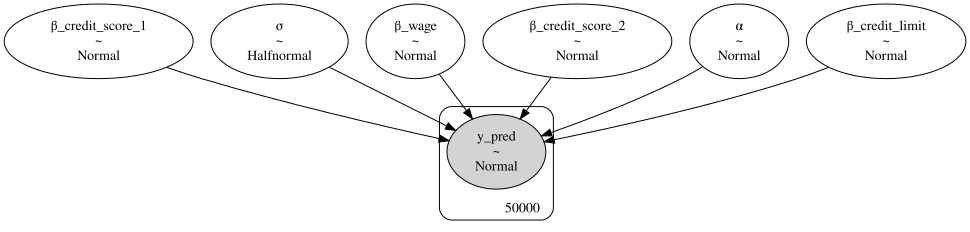

In [44]:
# plot graph
model_lr.to_graphviz()

In [63]:
# # Inspect model predictive accuracy
# # loo -> Compute Pareto-smoothed importance sampling leave-one-out cross-validation (PSIS-LOO-CV).
# # arviz_stats.loo_kfold()
# #   This method provides an unbiased estimate of model performance by ensuring each observation is used exactly once for testing.
# #   Unlike PSIS-LOO-CV (Pareto-smoothed importance sampling leave-one-out cross-validation), 
# #   which approximates cross-validation efficiently, K-fold requires actual model refitting but yields exact results.
# az.loo(
#     data=idata_lr
# )

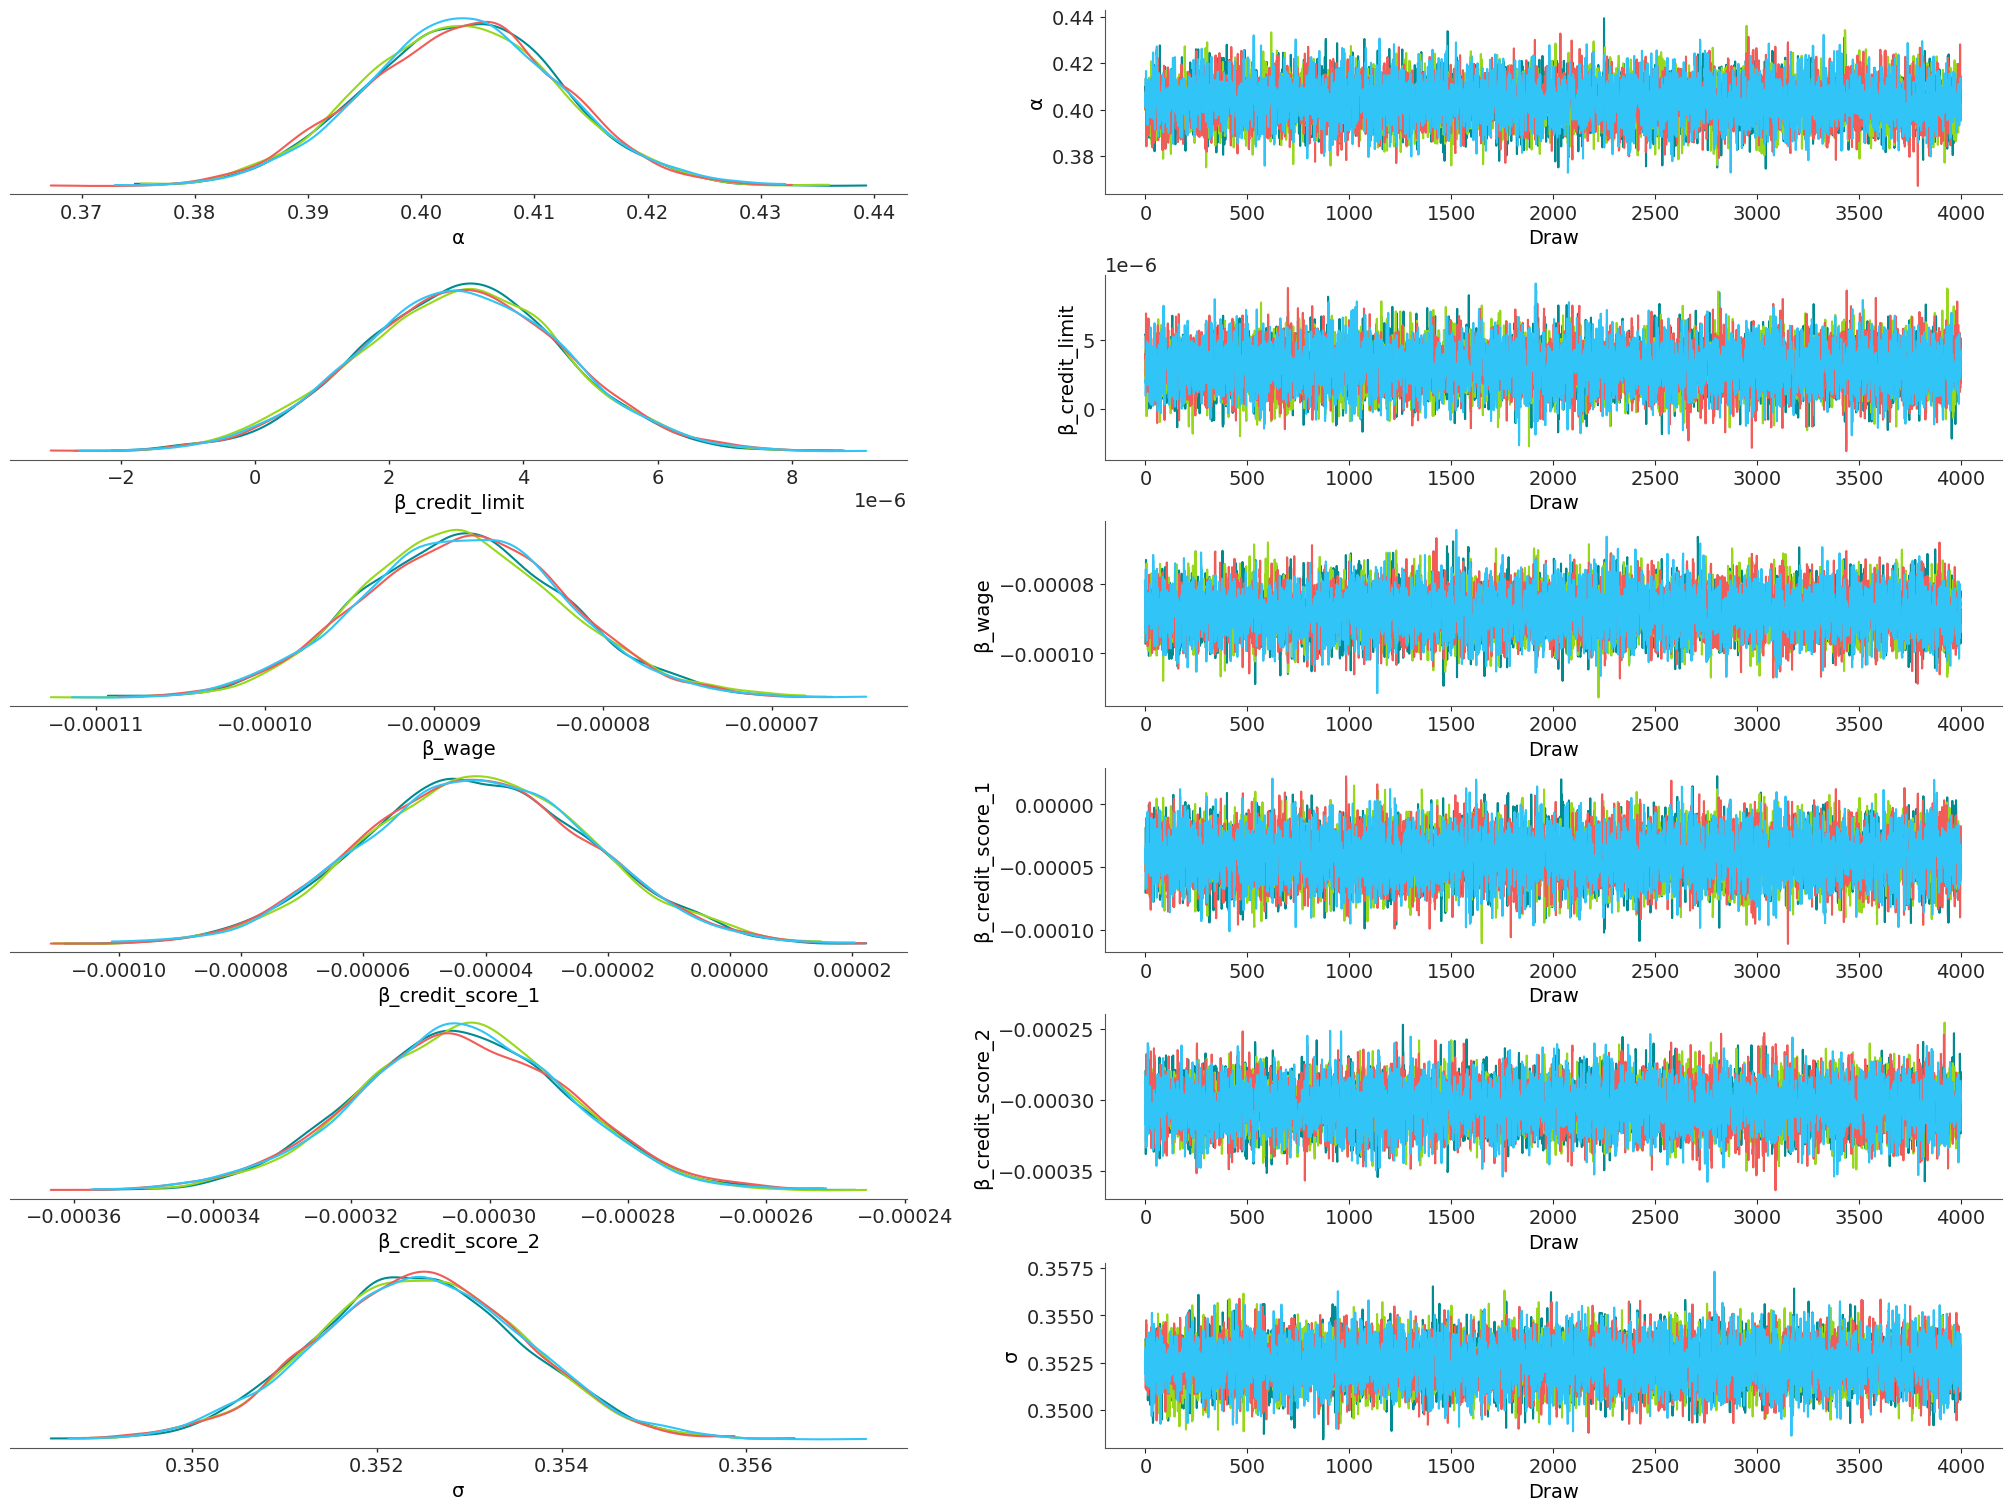

In [64]:

# Plot traces for convergence checking
az.plot_trace_dist(
    dt=idata_lr,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    compact=False, combined=False, kind=None, stats=None,
    figure_kwargs={"figsize": (20, 15)},
);

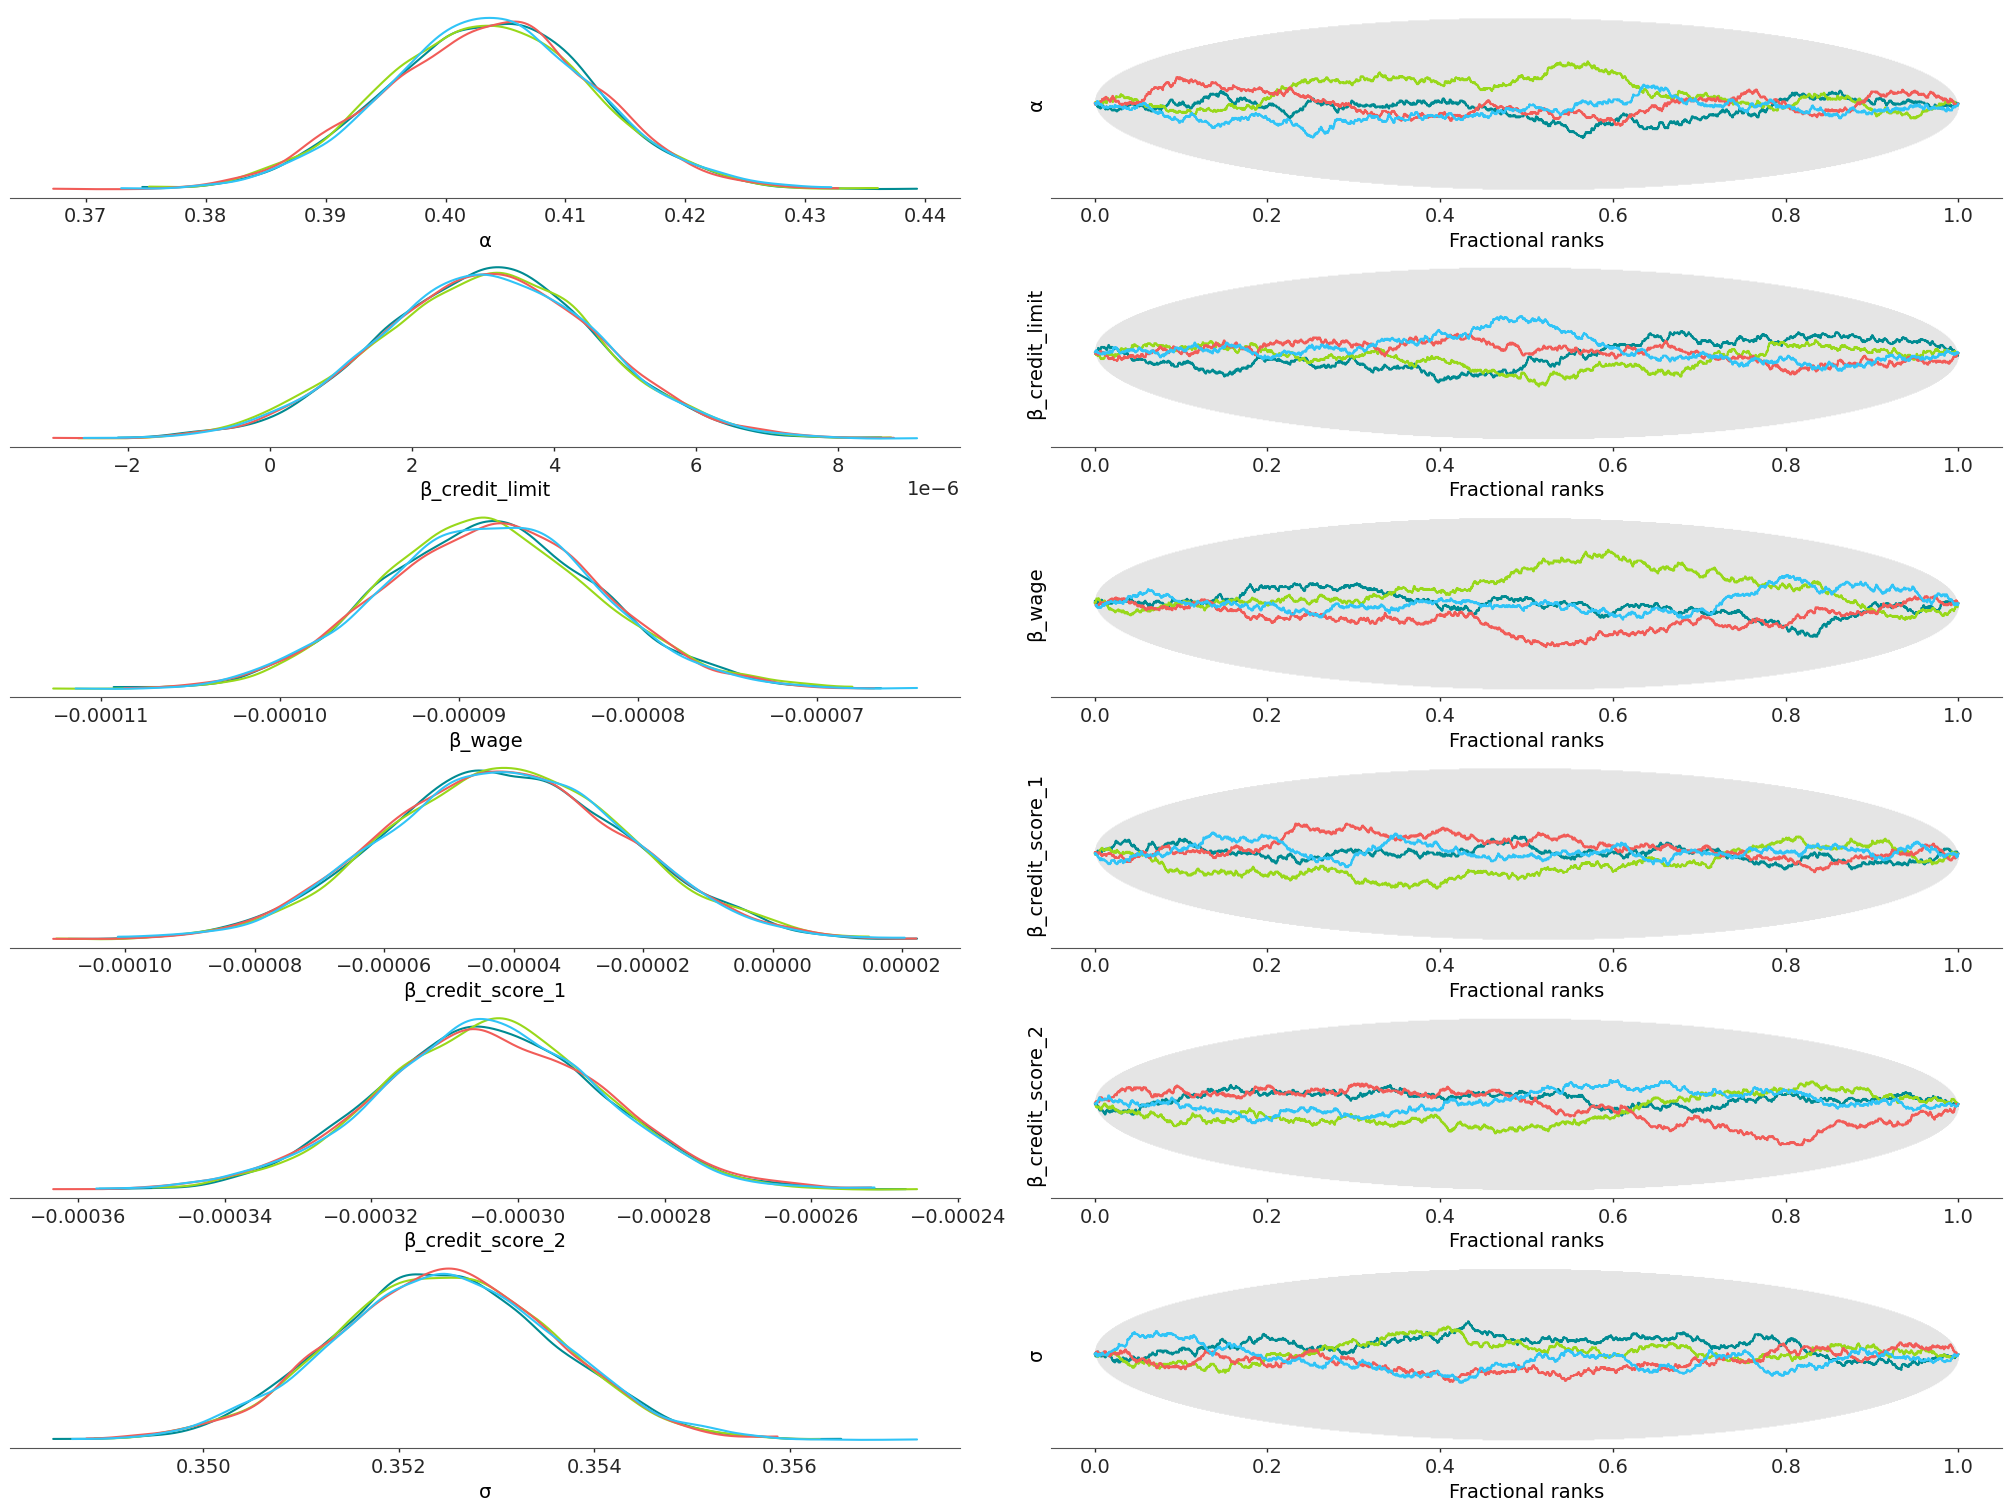

In [65]:
# Plot traces for convergence checking
az.plot_rank_dist(
    dt=idata_lr,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    compact=False, combined=False, kind=None, stats=None,
    figure_kwargs={"figsize": (20, 15)},
);

In [ ]:
# Inspect summary
# R hat
#   compute the variance between chains with the variance within chains
#   Ideally = 1, okay if < 1.01
# ESS (Effective Sample Size)
#   Less than the draws due to autocorrelation
#   At least 400 (100 ESS per chain) -> the higher the better
# MCSE - Monte Carlo Standard Error
#   Error introduced on MC posterior due to 
#   finite sampling and samples not being truely independent
#   It impact the precision of results
#   The pass criteria to check:
#       mcse_mean / sd (from the same table) below ~5–10%
#       If those all pass (R hat, ESS and MCSE), a U shape MCSE plot is fine as-is
#       the shape is just the normal signature of tail quantiles being harder to pin down.
summary = az.summary(
    data=idata_lr,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind='all', fmt='wide', ci_prob=0.95, ci_kind="hdi",
    round_to='auto', skipna=False
)

# Relative MCSE: how big is the sampling error compared to the posterior's own spread?
#   mcse_mean_pct = MCSE of the posterior mean, as a % of the posterior SD.
#       Rule of thumb: < 5–10% is fine; 
#       higher means you'd need more draws to trust the reported mean/HDI to that many significant digits.
#   mcse_sd_pct = same idea for the SD estimate.
summary["mcse_mean_pct"] = summary["mcse_mean"].astype(float) / summary["sd"].astype(float)
summary["mcse_sd_pct"]   = summary["mcse_sd"].astype(float)   / summary["sd"].astype(float)
summary = summary.astype("float")
summary

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,mcse_mean_pct,mcse_sd_pct
α,0.4036,0.0086,0.39,0.42,9175,9917,1.00,9e-05,6.3e-05,0.010465,0.007326
β_credit_limit,3.06e-06,1.54e-06,1.4e-08,6.1e-06,12293,11183,1.00,1.4e-08,9.9e-09,0.009091,0.006429
β_wage,-8.83e-05,6.08e-06,-0.0001,-7.6e-05,9877,10543,1.00,6.1e-08,4.4e-08,0.010033,0.007237
β_credit_score_1,-4.14e-05,1.85e-05,-7.7e-05,-5.2e-06,10057,10504,1.00,1.8e-07,1.3e-07,0.009730,0.007027
β_credit_score_2,-0.0003039,1.52e-05,-0.00033,-0.00027,10812,10700,1.00,1.5e-07,1e-07,0.009868,0.006579
σ,0.35247,0.00111,0.35,0.35,13539,10858,1.00,9.6e-06,6.7e-06,0.008649,0.006036


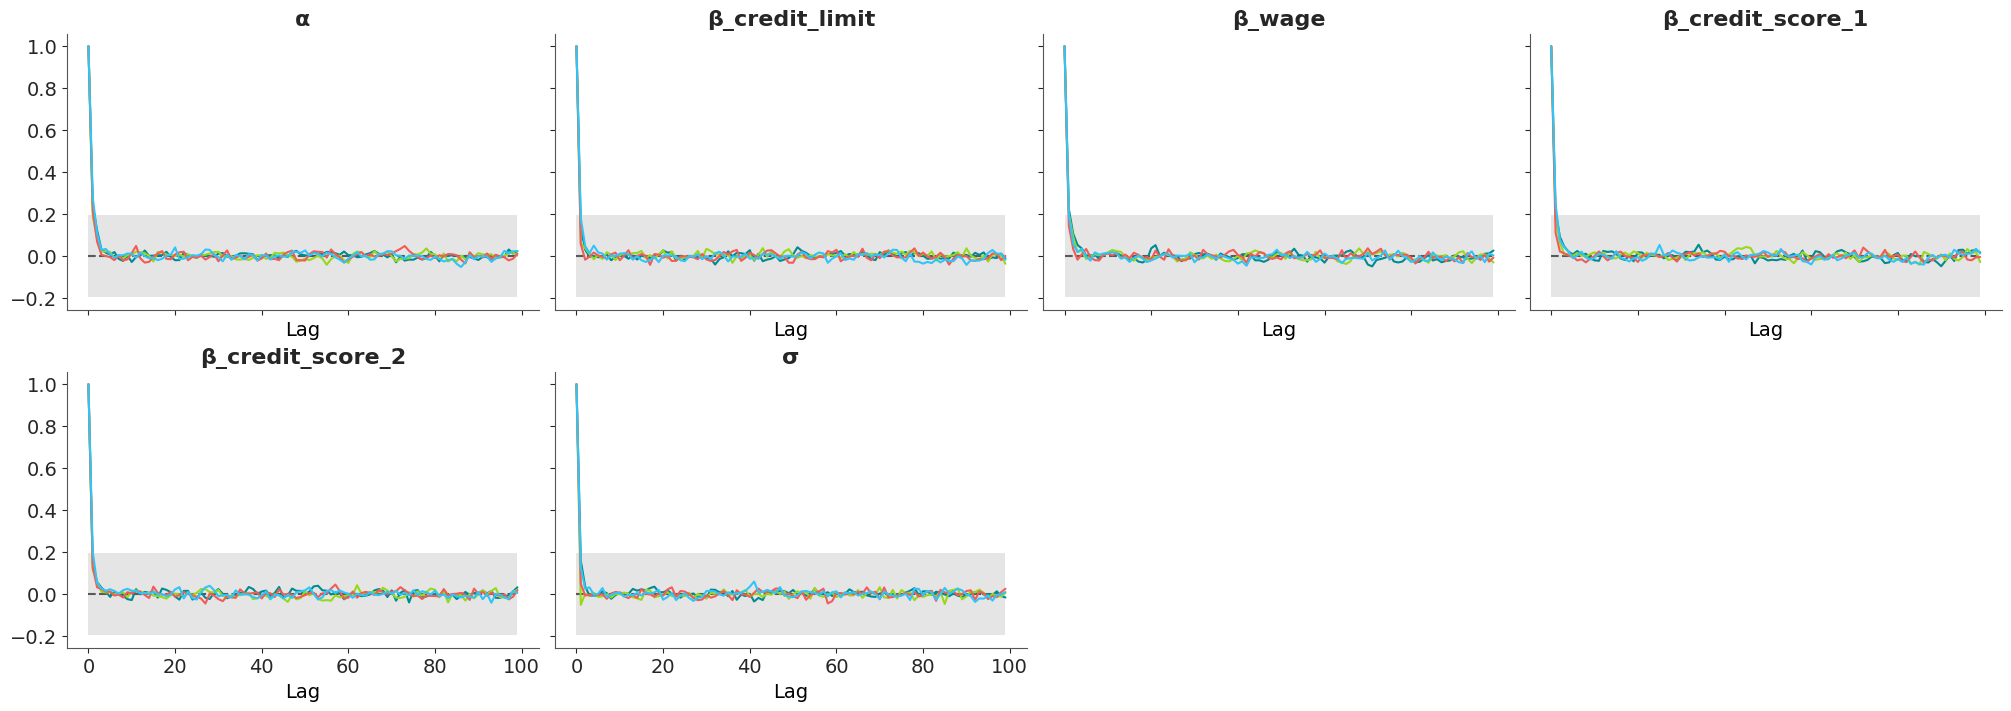

In [67]:
# Inspect autocorrelation
az.plot_autocorr(
    dt=idata_lr, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    max_lag=None,
    figure_kwargs={"figsize": (20, 7)}
);

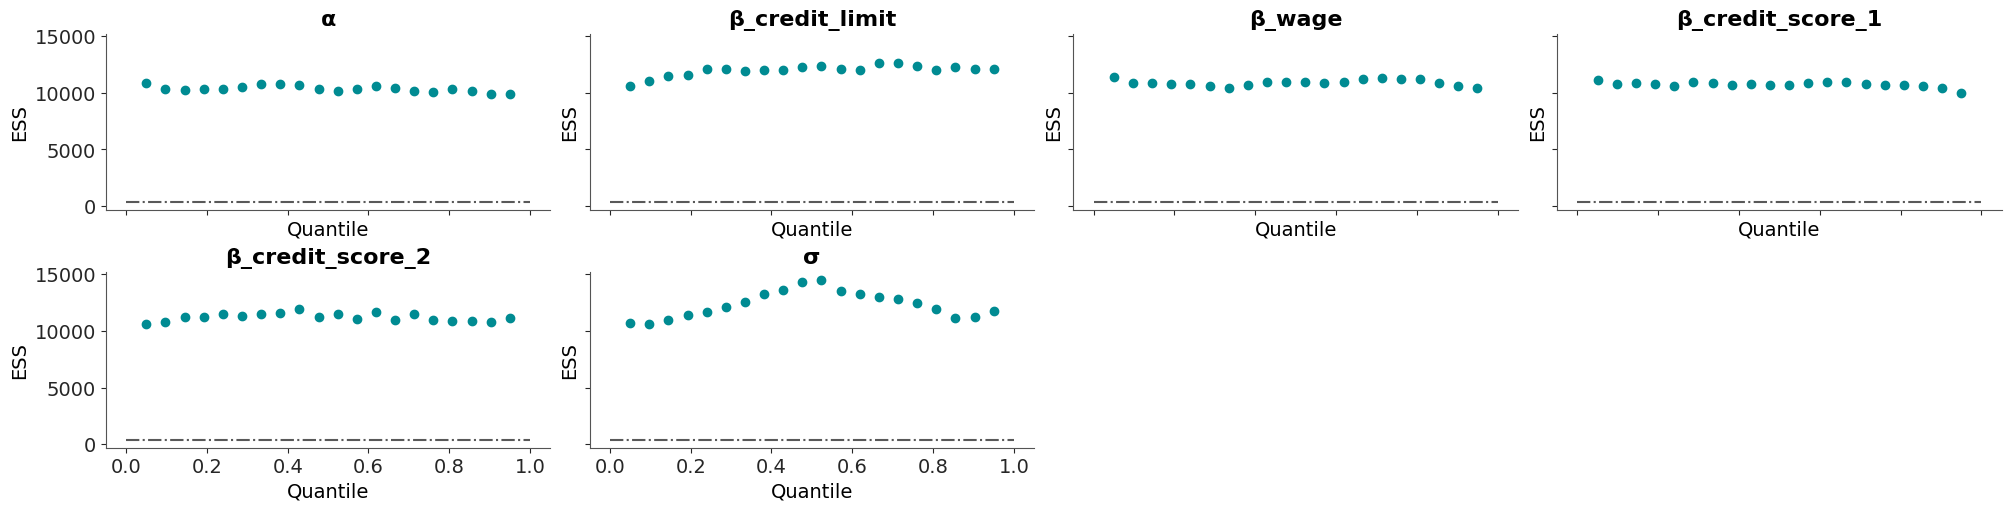

In [68]:
# Inspect ESS
# ESS (Effective Sample Size)
#   Less than the draws due to autocorrelation
#   At least 400 (100 ESS per chain) -> the higher the better
az.plot_ess(
    dt=idata_lr, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind='quantile', relative=False,
    extra_methods=False,    
    rug=False, rug_kind='diverging',
    n_points=20, min_ess=N_CHAINS*100, stats=None,
    figure_kwargs={"figsize": (20, 5)},
);

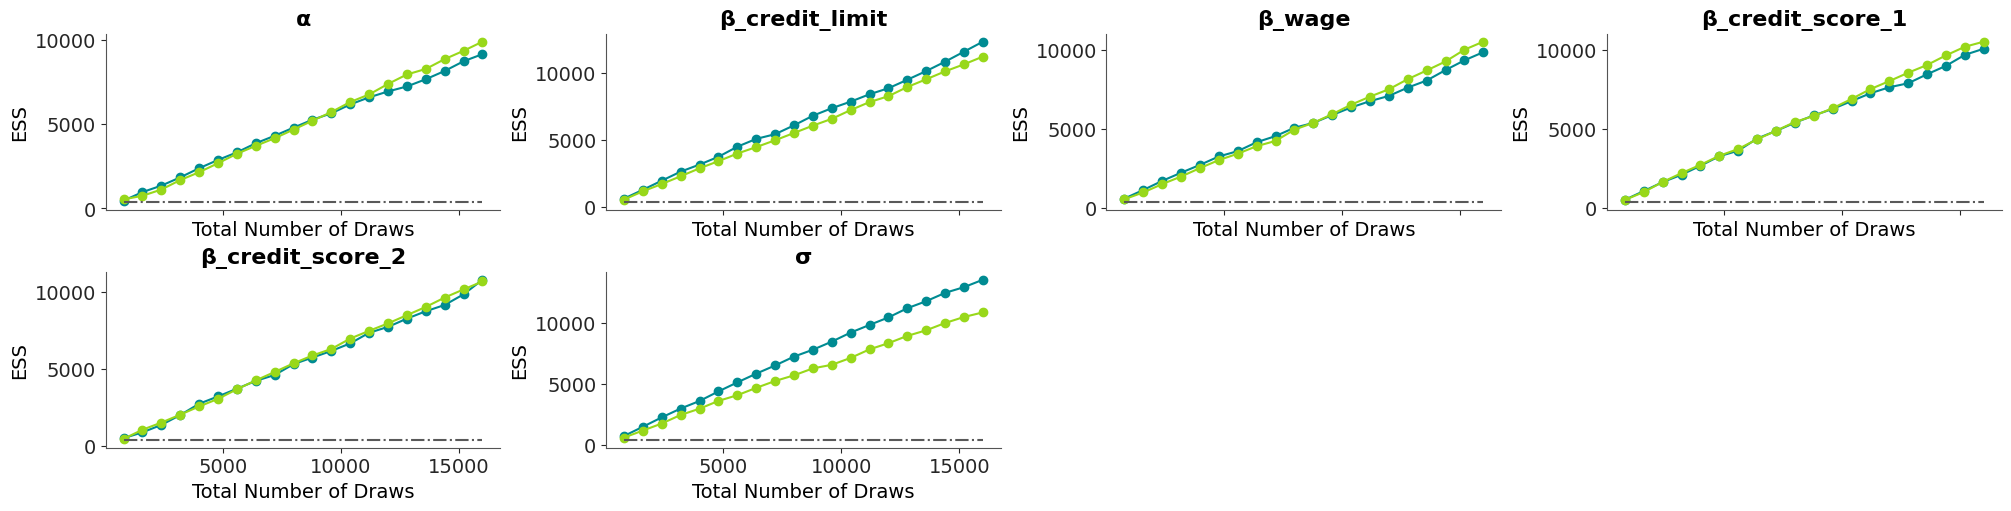

In [69]:
# Inspect ESS evolution
# ESS (Effective Sample Size)
#   Less than the draws due to autocorrelation
#   At least 400 (100 ESS per chain) -> the higher the better
az.plot_ess_evolution(
    dt=idata_lr, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    relative=False,
    extra_methods=False,
    n_points=20, min_ess=N_CHAINS*100,
    stats=None,
    figure_kwargs={"figsize": (20, 5)},
);

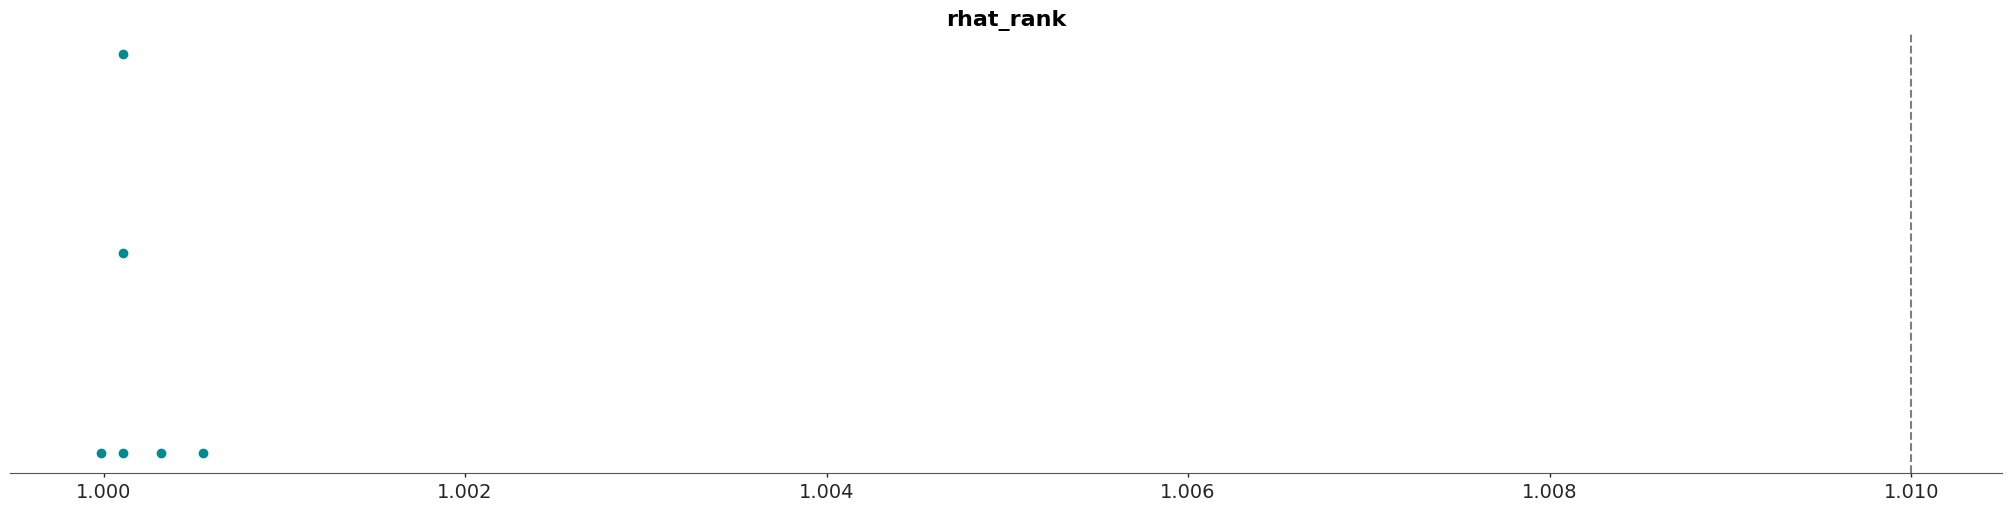

In [70]:
# Plot R hat convergence
# R hat
#   compute the variance between chains with the variance within chains
#   Ideally = 1, okay if < 1.01
az.plot_convergence_dist(
    dt=idata_lr, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None, ref_line=True,
    diagnostics=["rhat_rank"],
    grouped=True, #kind='ecdf',
    kind="dot",
    point_estimate=None, ci_kind=None, ci_prob=None,
    stats=None,
    figure_kwargs={"figsize": (20, 5)},
);

,mcse_mean_pct,mcse_sd_pct
α,0.010465,0.007326
β_credit_limit,0.009091,0.006429
β_wage,0.010033,0.007237
β_credit_score_1,0.009730,0.007027
β_credit_score_2,0.009868,0.006579
σ,0.008649,0.006036


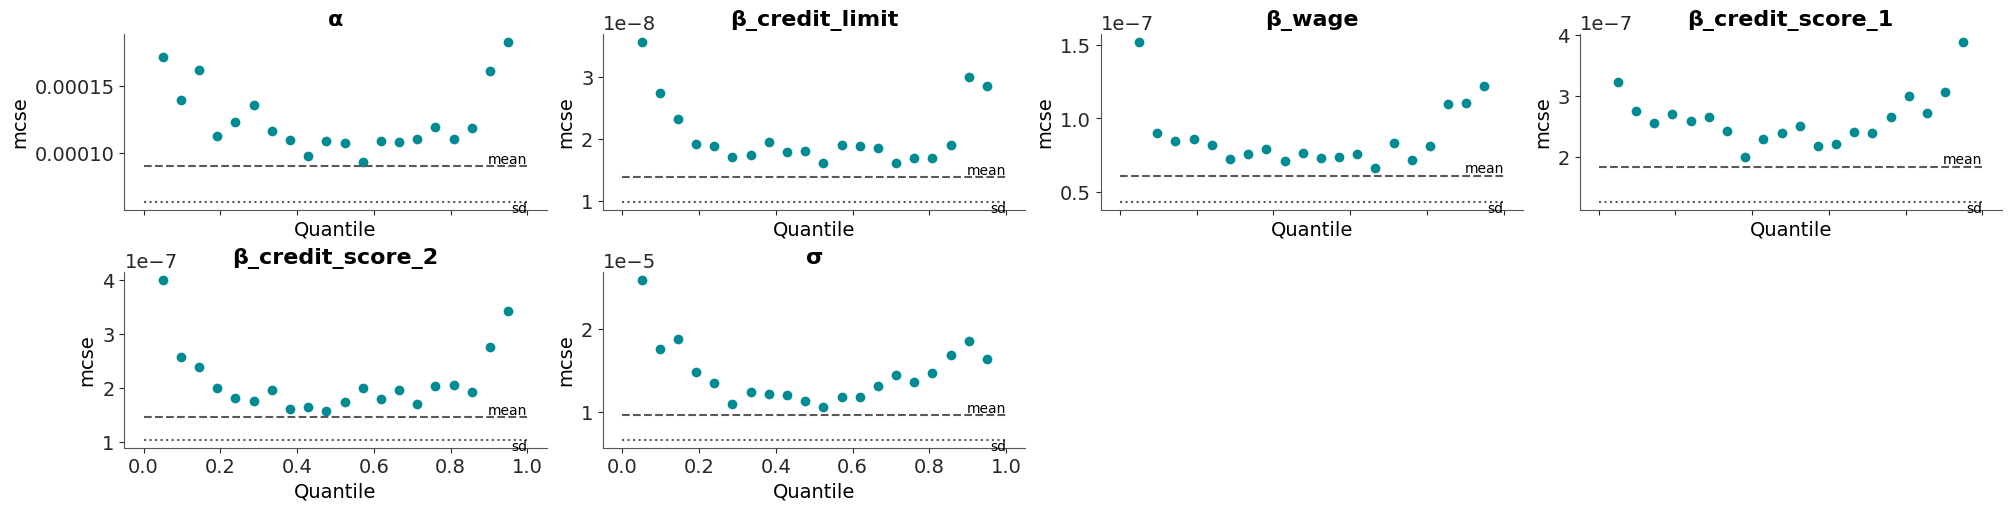

In [71]:
# Inspect MCSE - Monte Carlo Standard Error
#   Error introduced on MC posterior due to 
#   finite sampling and samples not being truely independent
#   It impact the precision of results
# extra_methods overlays two dashed horizontal lines per subplot:
#   the MCSE of the posterior mean, and 
#   the MCSE of the posterior sd. 
#   if your quantile-based MCSE curve sits near or below these lines,
#   you're in good shape; if it spikes well above them 
#   (especially at the tails, as in your α and σ panels),
#   that quantile's estimate is comparatively less precise.
#   The pattern with quantile MCSE tracing a U-shape, 
#   worse at the tails (0.05/0.95) than the middle, 
#   and sitting above both the mean-MCSE and sd-MCSE reference lines — is the expected, 
#   typical shape, not a red flag by itself. It reflects real statistical facts:
#   Tail quantiles always have lower effective sample size than central quantiles/the mean, since fewer draws inform them.
#       The posterior mean is usually the most efficiently estimated summary statistic,
#       so mean-MCSE is the lowest baseline; sd and quantiles are inherently noisier estimators.
#       So "quantile MCSE > mean line > sd line" is normal ordering, not evidence of a sampling problem.
az.plot_mcse(
    dt=idata_lr, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    extra_methods=True,
    rug=False, rug_kind='diverging',
    n_points=20, stats=None,
    figure_kwargs={"figsize": (20, 5)},
);

# Relative MCSE: how big is the sampling error compared to the posterior's own spread?
#   mcse_mean_pct = MCSE of the posterior mean, as a % of the posterior SD.
#       Rule of thumb: < 5–10% is fine; 
#       higher means you'd need more draws to trust the reported mean/HDI to that many significant digits.
#   mcse_sd_pct = same idea for the SD estimate.
summary = az.summary(
    data=idata_lr,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind='all', fmt='wide', ci_prob=0.95, ci_kind="hdi",
    round_to='auto', skipna=False
)
summary["mcse_mean_pct"] = summary["mcse_mean"].astype(float) / summary["sd"].astype(float)
summary["mcse_sd_pct"]   = summary["mcse_sd"].astype(float)   / summary["sd"].astype(float)
summary[["mcse_mean_pct", "mcse_sd_pct"]]

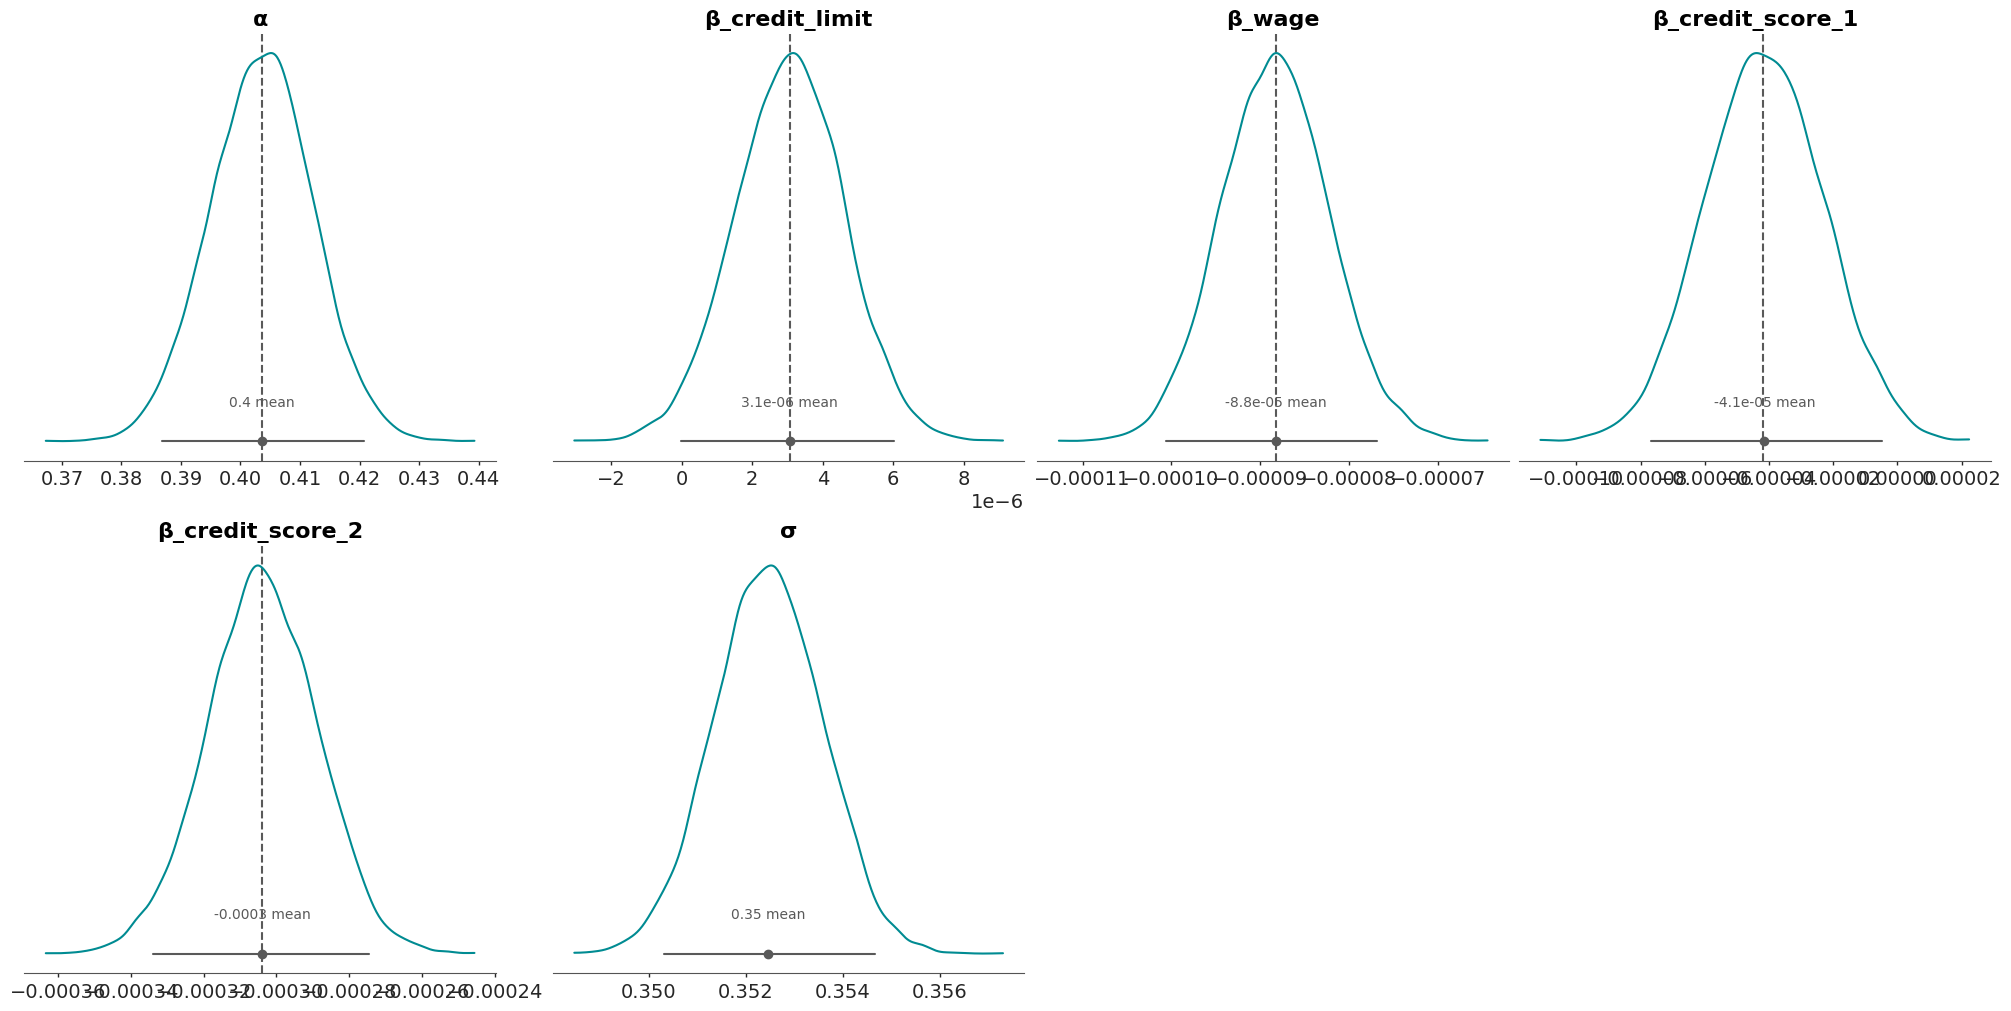

In [72]:
# Inspect posteriors
pc = az.plot_dist(
    dt=idata_lr,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind=None, point_estimate="mean",
    ci_kind="hdi", ci_prob=0.95, stats=None,
    visuals={"point_estimate_text": True},
    figure_kwargs={"figsize": (20, 10)},
)
az.add_lines(
    plot_collection=pc,
    values={
        "α": model.params["Intercept"],
        "β_credit_limit": model.params["credit_limit"],
        "β_wage": model.params["wage"],
        "β_credit_score_1": model.params["credit_score1"],
        "β_credit_score_2": model.params["credit_score2"],
    },
    orientation="vertical"
);

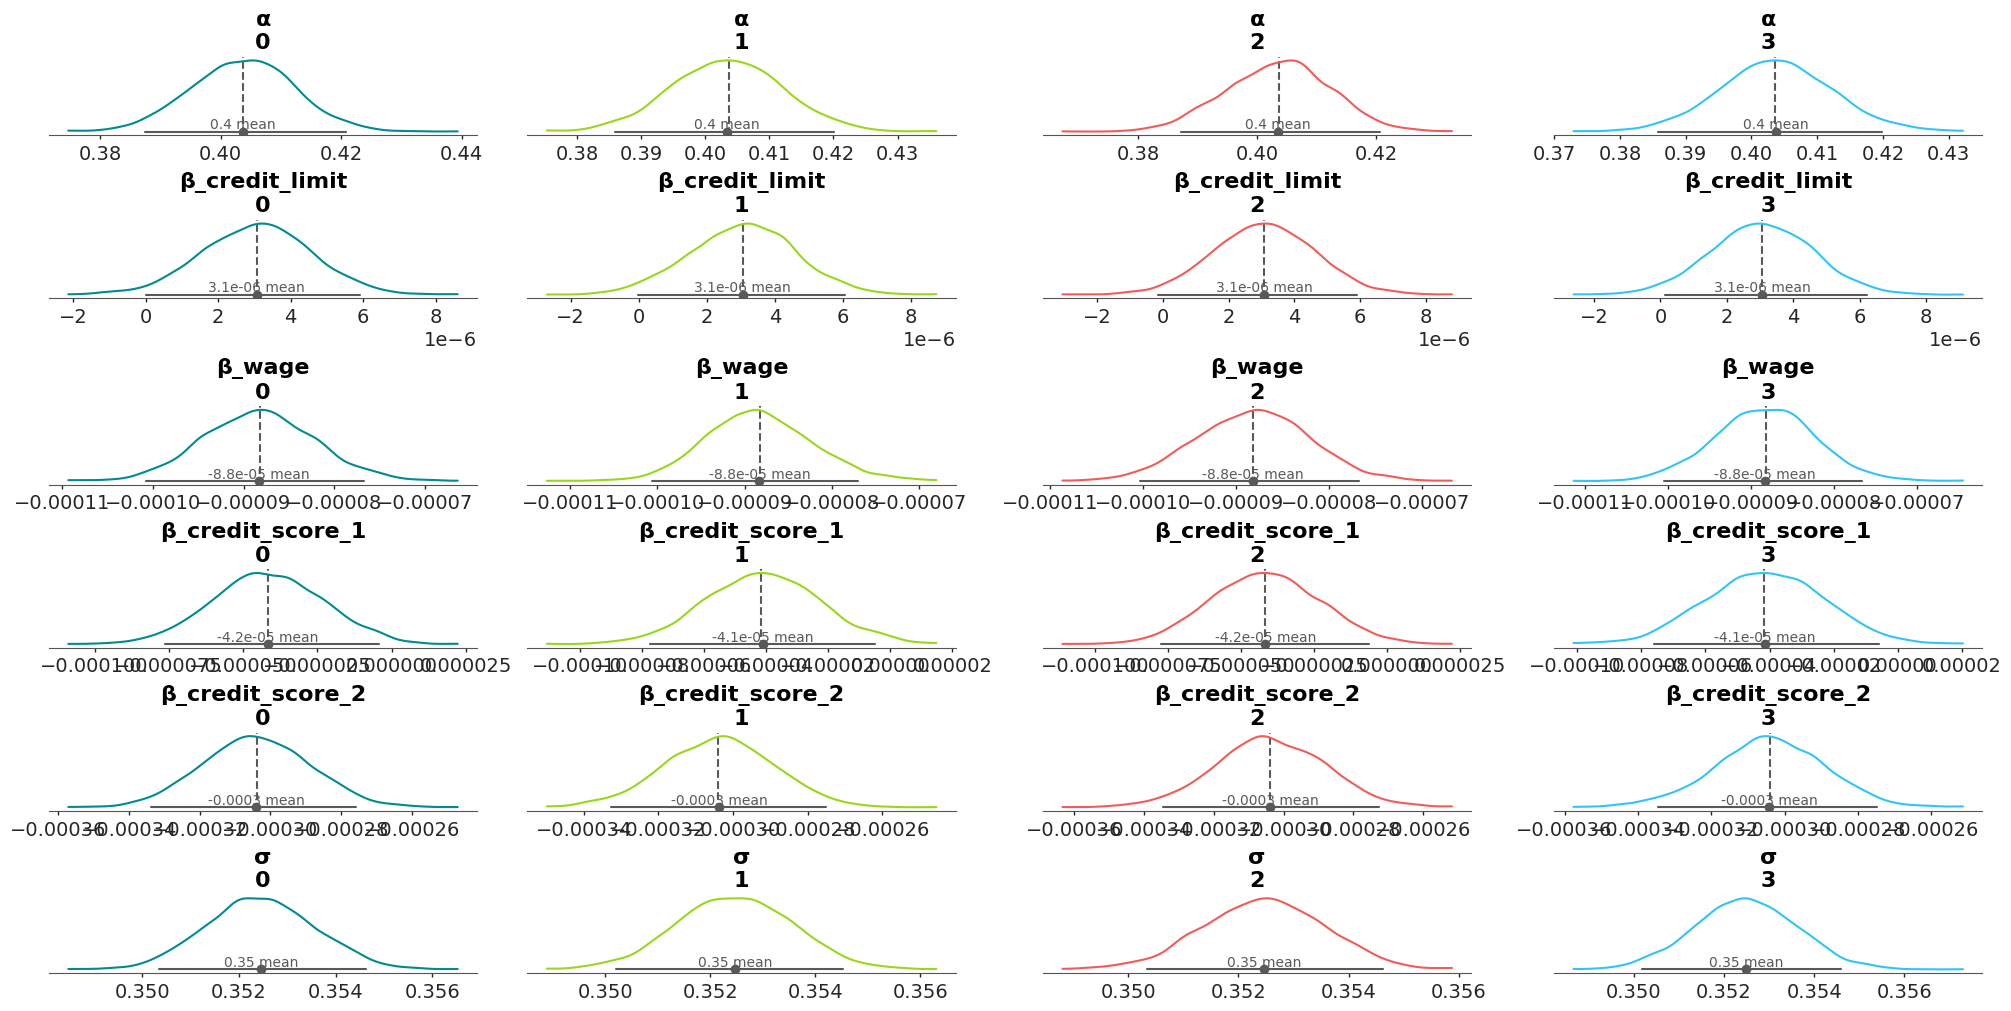

In [73]:
# Inspect posteriors
pc = az.plot_dist(
    dt=idata_lr,
    var_names=None, filter_vars=None,
    group='posterior', coords=None,
    sample_dims=["draw"],
    aes={"color": ["chain"]},
    kind=None, point_estimate="mean",
    ci_kind="hdi", ci_prob=0.95, stats=None,
    visuals={"point_estimate_text": True},
    figure_kwargs={"figsize": (20, 10)},
)
az.add_lines(
    plot_collection=pc,
    values={
        "α": model.params["Intercept"],
        "β_credit_limit": model.params["credit_limit"],
        "β_wage": model.params["wage"],
        "β_credit_score_1": model.params["credit_score1"],
        "β_credit_score_2": model.params["credit_score2"],
    },
    orientation="vertical"
);

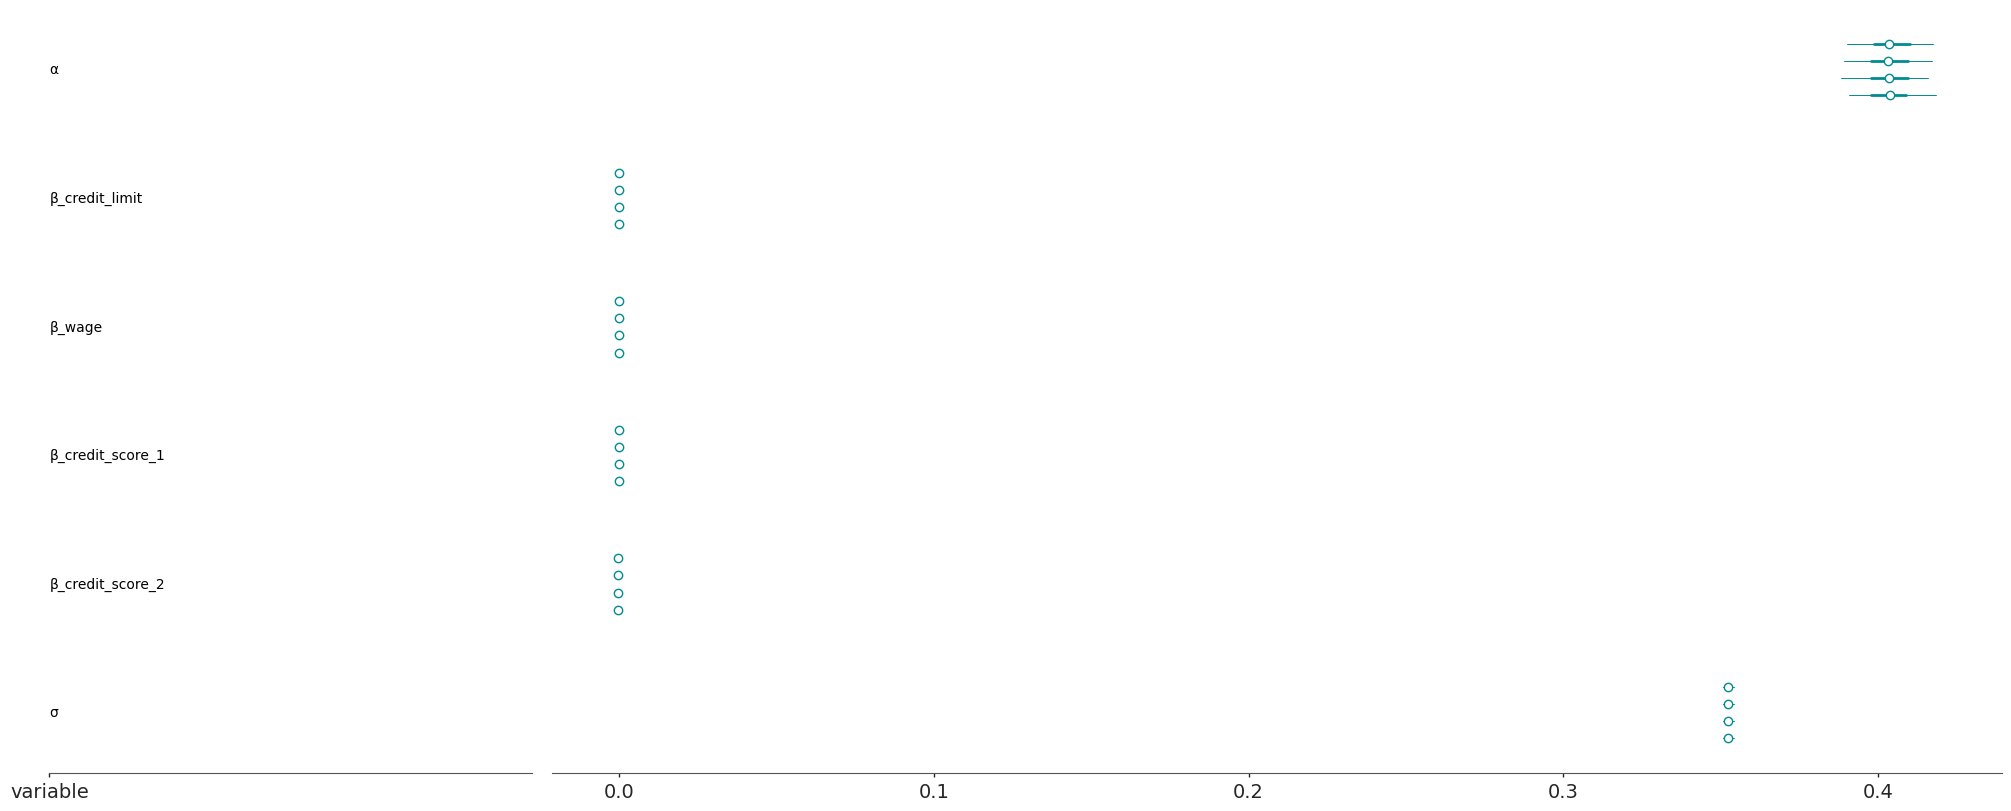

In [74]:
# Plot results
az.plot_forest(
    dt=idata_lr, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    combined=False, point_estimate="mean", ci_kind="hdi", ci_probs=None,
    labels=None, stats=None,
    figure_kwargs={"figsize": (20, 8)},
);

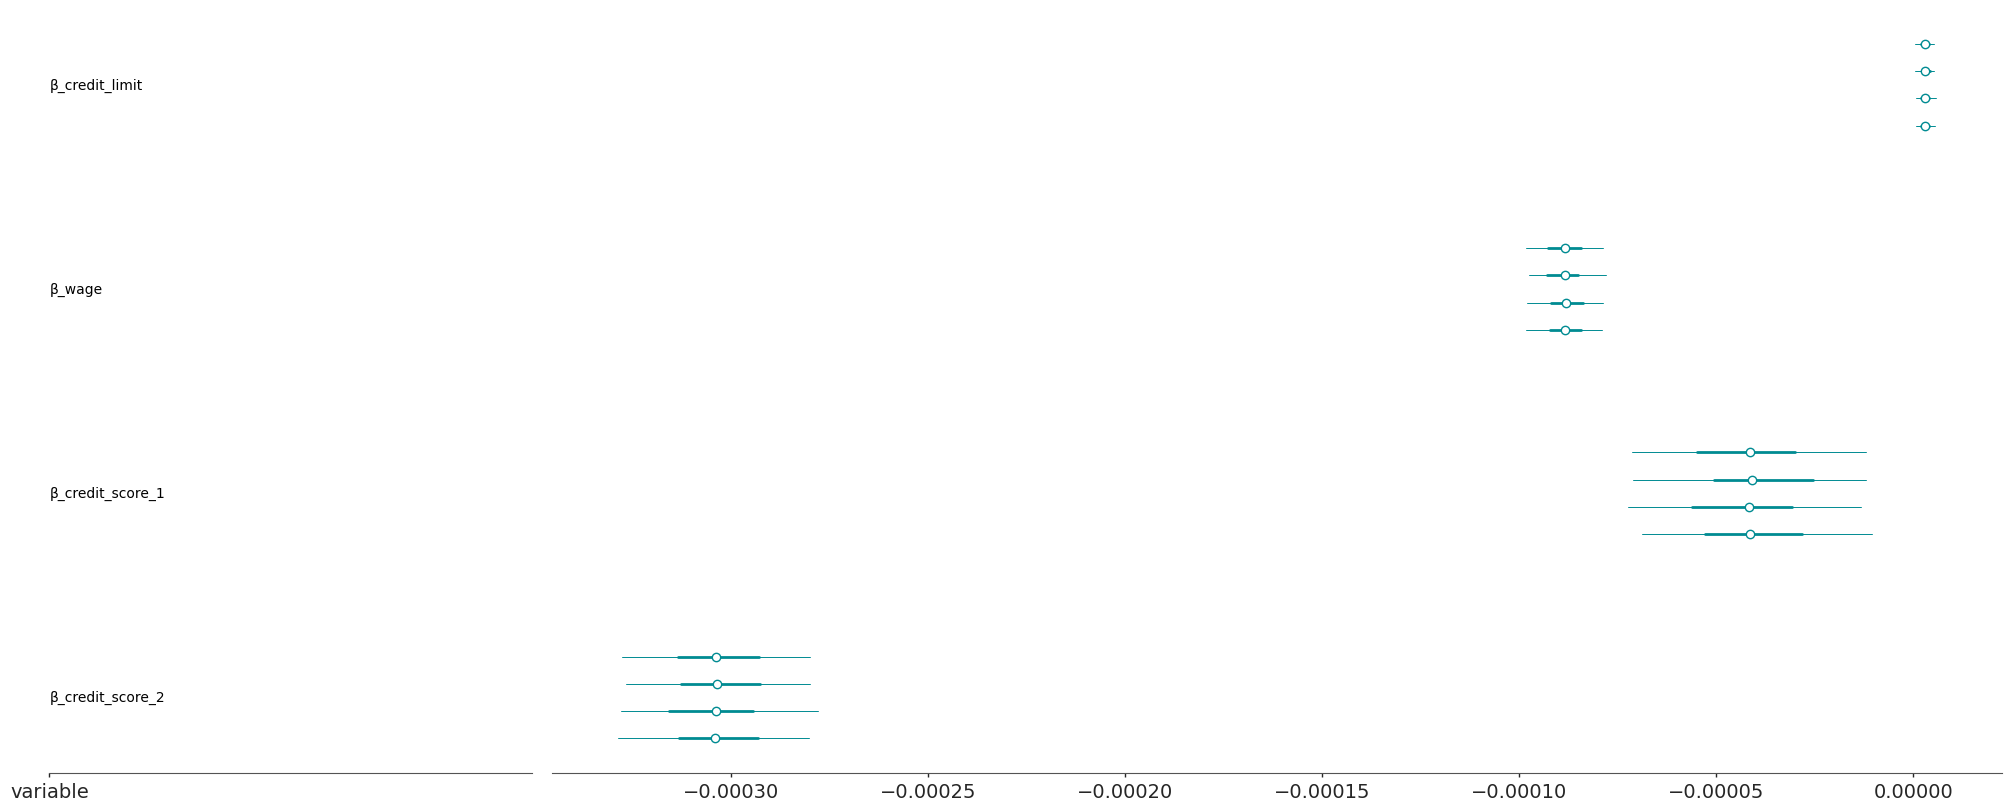

In [75]:
# Plot results
az.plot_forest(
    dt=idata_lr, 
    var_names=["~α", "~σ"], filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    combined=False, point_estimate="mean", ci_kind="hdi", ci_probs=None,
    labels=None, stats=None,
    figure_kwargs={"figsize": (20, 8)},
);

In [ ]:
# Get a slice of inference data to avoid OOM
idata_lr_slice = idata_lr.sel(draw=slice(0, 100))  # get first 500 draws from all chains

# Get posterior predictive
with model_lr:
    pm.sample_posterior_predictive(
        trace=idata_lr_slice,
        random_seed=SEED, progressbar=True,
        return_inferencedata=True, extend_inferencedata=True
    )

# Inspect posterior predictive
az.plot_ppc_dist(
    dt=idata_lr_slice, 
    var_names=None, filter_vars=None,
    group='posterior_predictive', coords=None, sample_dims=None,
    kind=None, num_samples=100, stats=None,
    figure_kwargs={"figsize": (20, 8)},
)

Sampling: [y_pred]


Output()

/home/gus-cunha/.pyenv/versions/3.12.3/envs/bayesian_causal_inference_study/lib/python3.12/site-packages/arviz_plots/plots/ppc_dist_plot.py:208: UserWarning: The observed data looks binary. For binary outcomes, plot_ppc_pava may be more appropriate.
  warn_if_binary(observed_dist, predictive_dist)


KeyboardInterrupt: 

# HIERARCHICAL DUMMY VARIABLES

In [ ]:
# Load data
df_lr_dummies = pd.read_csv(os.path.join(ROOT_PATH, "data", "causal_inference_in_python_linear_regression_dummies.csv"))

# Print buckets
print(
    f"Unique credit_score1_buckets: {sorted(df_lr_dummies.credit_score1_buckets.unique())}"
)
df_lr_dummies

In [ ]:
###############################
######### FREQUENTIST #########

# Get dummies per credit score 1 buckets
df_lr_dummies_freq = (
    df_lr_dummies.join(
        other=pd.get_dummies(data=df_lr_dummies["credit_score1_buckets"], prefix="sb", drop_first=True),
        on=None,  # Index
        how="left"
    )
)
# Inspect data
display(df_lr_dummies_freq.sample(5))

# Define model and fit to data
model = smf.ols(
    formula="default ~ credit_limit + sb_200 + sb_400 + sb_600 + sb_800 + sb_1000",
    data=df_lr_dummies_freq
).fit()
# Inspect results
model.summary().tables[1]

In [ ]:
############################
######### BAYESIAN #########

# Get credit score buckets categories
categories = sorted(df_lr_dummies.credit_score1_buckets.unique())
# Encode credit score buckets
categories_encode = pd.Categorical(
    values=df_lr_dummies.credit_score1_buckets,
    categories=categories
)
# Get credit score index
categories_idx= categories_encode.codes
# Inspect results
print(
    f"credit_score1_buckets: {df_lr_dummies.credit_score1_buckets.values}\n"
    f"categories_encode: {categories_encode}\n"
    f"categories_encode.categories: {categories_encode.categories}\n"
    f"categories_idx: {categories_idx}\n"
)

# Get coordinate dict for modelling
coordinate_dict = {
    "credit_score1_buckets": categories_encode.categories,
}


with pm.Model(coords=coordinate_dict) as model_lr_dummies_unpooled:
    # Priors
    α = pm.Normal("α", mu=0, sigma=100, dims="credit_score1_buckets")
    β_credit_limit = pm.Normal("β_credit_limit", mu=0, sigma=10)
    σ = pm.HalfNormal("σ", 10)
    # Likelihood
    μ = (
        α[categories_idx] + 
        β_credit_limit * df_lr_dummies.credit_limit
    )
    y_pred = pm.Normal("y_pred", mu=μ, sigma=σ, observed=df_lr_dummies.default)
    # MCMC sampling
    idata_lr_dummies_unpooled = pm.sample(
        nuts_sampler="nutpie",
        draws=4_000,
        tune=1_000,
        chains=N_CHAINS,
        cores=N_CHAINS,
        random_seed=SEED,
        progressbar=True,
        discard_tuned_samples=True,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}        
    )

In [ ]:
# # Inspect model predictive accuracy
# # loo -> Compute Pareto-smoothed importance sampling leave-one-out cross-validation (PSIS-LOO-CV).
# # arviz_stats.loo_kfold()
# #   This method provides an unbiased estimate of model performance by ensuring each observation is used exactly once for testing.
# #   Unlike PSIS-LOO-CV (Pareto-smoothed importance sampling leave-one-out cross-validation), 
# #   which approximates cross-validation efficiently, K-fold requires actual model refitting but yields exact results.
# az.loo(
#     data=idata_lr_dummies_unpooled
# )

In [ ]:
# Inspect posteriors
pc = az.plot_dist(
    dt=idata_lr_dummies_unpooled,
    var_names=["~σ"], filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind=None, point_estimate="mean",
    ci_kind="hdi", ci_prob=0.95, stats=None,
    visuals={"point_estimate_text": True},
    figure_kwargs={"figsize": (20, 12)},
)
# Add frequentist vertical lines
baseline = categories[0]  # category dropped by drop_first=True
alpha_ref = np.array([
    model.params["Intercept"] + model.params.get(f"sb_{cat}[T.True]", 0.0)
    for cat in categories
])
ref_ds = xr.Dataset(
    {
        "α": (("credit_score1_buckets",), alpha_ref),
        "β_credit_limit": ((), model.params["credit_limit"]),
    },
    coords={"credit_score1_buckets": categories},
)

az.add_lines(
    plot_collection=pc,
    values=ref_ds,   # a Dataset is used as-is and aligns by the shared coordinate
    orientation="vertical",
);


In [ ]:
################################
######### HYPER PRIORS #########

pz.HalfNormal(sigma=1).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()

In [ ]:
# Find the maximum-entropy for Normal distribution
dist_mu = pz.Normal()
pz.maxent(
    distribution=dist_mu, lower=-5, upper=5, mass=0.95,
    fixed_stat=None, fixed_params=None,
    plot=True, plot_kwargs={"figsize": (10, 5)},
)

# Find the maximum-entropy for Normal distribution
dist_sigma = pz.HalfNormal()
pz.maxent(
    distribution=dist_sigma, lower=0, upper=5, mass=0.95,
    fixed_stat=None, fixed_params=None,
    plot=True, plot_kwargs={"figsize": (10, 5)},
)

print(
    dist_mu.params_dict,
    dist_sigma.params_dict
)

In [ ]:
############################
######### BAYESIAN #########

# Get credit score buckets categories
categories = sorted(df_lr_dummies.credit_score1_buckets.unique())
# Encode credit score buckets
categories_encode = pd.Categorical(
    values=df_lr_dummies.credit_score1_buckets,
    categories=categories
)
# Get credit score index
categories_idx= categories_encode.codes
# Inspect results
print(
    f"credit_score1_buckets: {df_lr_dummies.credit_score1_buckets.values}\n"
    f"categories_encode: {categories_encode}\n"
    f"categories_encode.categories: {categories_encode.categories}\n"
    f"categories_idx: {categories_idx}\n"
)

# Get coordinate dict for modelling
coordinate_dict = {
    "credit_score1_buckets": categories_encode.categories,
}


with pm.Model(coords=coordinate_dict) as model_lr_dummies_hierarchical:
    # Hyperpriors
    hyper_mu = pm.Normal("hyper_mu", mu=dist_mu.params_dict["mu"], sigma=dist_mu.params_dict["sigma"])
    hyper_sigma = pm.HalfNormal("hyper_sigma", sigma=dist_sigma.params_dict["sigma"])
    # Priors
    α = pm.Normal("α", mu=hyper_mu, sigma=hyper_sigma, dims="credit_score1_buckets")
    β_credit_limit = pm.Normal("β_credit_limit", mu=0, sigma=10)
    σ = pm.HalfNormal("σ", 10)
    # Likelihood
    μ = (
        α[categories_idx] + 
        β_credit_limit * df_lr_dummies.credit_limit
    )
    y_pred = pm.Normal("y_pred", mu=μ, sigma=σ, observed=df_lr_dummies.default)
    # MCMC sampling
    idata_lr_dummies_hierarchical = pm.sample(
        nuts_sampler="nutpie",
        draws=4_000,
        tune=1_000,
        chains=N_CHAINS,
        cores=N_CHAINS,
        random_seed=SEED,
        progressbar=True,
        discard_tuned_samples=True,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}
    )

In [ ]:
# # Inspect model predictive accuracy
# # loo -> Compute Pareto-smoothed importance sampling leave-one-out cross-validation (PSIS-LOO-CV).
# # arviz_stats.loo_kfold()
# #   This method provides an unbiased estimate of model performance by ensuring each observation is used exactly once for testing.
# #   Unlike PSIS-LOO-CV (Pareto-smoothed importance sampling leave-one-out cross-validation), 
# #   which approximates cross-validation efficiently, K-fold requires actual model refitting but yields exact results.
# az.loo(
#     data=idata_lr_dummies_hierarchical
# )

In [ ]:
# Inspect posteriors
pc = az.plot_dist(
    dt=idata_lr_dummies_hierarchical,
    var_names=["~σ", "~hyper_mu", "~hyper_sigma"], filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind=None, point_estimate="mean",
    ci_kind="hdi", ci_prob=0.95, stats=None,
    visuals={"point_estimate_text": True},
    figure_kwargs={"figsize": (20, 12)},
)
# Add frequentist vertical lines
baseline = categories[0]  # category dropped by drop_first=True
alpha_ref = np.array([
    model.params["Intercept"] + model.params.get(f"sb_{cat}[T.True]", 0.0)
    for cat in categories
])
ref_ds = xr.Dataset(
    {
        "α": (("credit_score1_buckets",), alpha_ref),
        "β_credit_limit": ((), model.params["credit_limit"]),
    },
    coords={"credit_score1_buckets": categories},
)

az.add_lines(
    plot_collection=pc,
    values=ref_ds,   # a Dataset is used as-is and aligns by the shared coordinate
    orientation="vertical",
);

In [ ]:
# Display number of samples on each categories
display(model.summary().tables[1])
display(df_lr_dummies.credit_score1_buckets.value_counts().sort_index())

# Plot results
pc = az.plot_forest(
    dt={
            "unpooled": idata_lr_dummies_unpooled,
            "hierarchical": idata_lr_dummies_hierarchical
    }, 
    var_names=["~σ", "~hyper_mu", "~hyper_sigma"], filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    combined=False, point_estimate="mean", ci_kind="hdi", ci_probs=None,
    labels=None, stats=None,
    figure_kwargs={"figsize": (15, 20)},
)
pc.add_legend(dim="model");

# LOGISTIC REGRESSION

In [ ]:
# Load data
df_lr = pd.read_csv(os.path.join(ROOT_PATH, "data", "causal_inference_in_python_linear_regression.csv"))
df_lr

In [ ]:
# Standardize features
for col in ["credit_limit", "wage", "credit_score1", "credit_score2"]:
    df_lr[f"{col}_z"] = (df_lr[col] - df_lr[col].mean()) / df_lr[col].std(ddof=1)

# Inspect dataframe
df_lr

In [ ]:
###############################
######### FREQUENTIST #########

# Define formula, where T = credit limit
formula = 'default ~ credit_limit_z + wage_z + credit_score1_z + credit_score2_z'
# Fit model to data
model = smf.ols(formula, data=df_lr).fit()
# Inspect results
model.summary().tables[1]

In [ ]:
###############################
######### FREQUENTIST #########

# Define formula, where T = credit limit
formula = 'default ~ credit_limit_z + wage_z + credit_score1_z + credit_score2_z'
# Fit model to data
model = smf.logit(formula, data=df_lr).fit()
# Inspect results
model.summary().tables[1]

In [ ]:
##########################
######### PRIORS #########

pz.Normal(mu=0, sigma=5).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()
pz.HalfNormal(sigma=5).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()

In [ ]:
############################
######### BAYESIAN #########

with pm.Model() as model_linear_regression:
    # Priors
    α = pm.Normal("α", mu=0, sigma=5)
    β_credit_limit = pm.Normal("β_credit_limit", mu=0, sigma=5)
    β_wage = pm.Normal("β_wage", mu=0, sigma=5)
    β_credit_score_1 = pm.Normal("β_credit_score_1", mu=0, sigma=5)
    β_credit_score_2 = pm.Normal("β_credit_score_2", mu=0, sigma=5)
    σ = pm.HalfNormal("σ", 5)
    # Likelihood
    μ = (
        α + 
        β_credit_limit * df_lr.credit_limit_z + 
        β_wage * df_lr.wage_z + 
        β_credit_score_1 * df_lr.credit_score1_z + 
        β_credit_score_2 * df_lr.credit_score2_z
    )
    y_pred = pm.Normal("y_pred", mu=μ, sigma=σ, observed=df_lr.default)
    # MCMC sampling
    idata_linear_regression = pm.sample(
        nuts_sampler="nutpie",
        draws=4_000,
        tune=1_000,
        chains=N_CHAINS,
        cores=N_CHAINS,
        random_seed=SEED,
        progressbar=True,
        discard_tuned_samples=True,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}        
    )

In [ ]:
# # Inspect model predictive accuracy
# # loo -> Compute Pareto-smoothed importance sampling leave-one-out cross-validation (PSIS-LOO-CV).
# # arviz_stats.loo_kfold()
# #   This method provides an unbiased estimate of model performance by ensuring each observation is used exactly once for testing.
# #   Unlike PSIS-LOO-CV (Pareto-smoothed importance sampling leave-one-out cross-validation), 
# #   which approximates cross-validation efficiently, K-fold requires actual model refitting but yields exact results.
# az.loo(
#     data=idata_linear_regression
# )

In [ ]:
# Inspect posteriors
pc = az.plot_dist(
    dt=idata_linear_regression,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind=None, point_estimate="mean",
    ci_kind="hdi", ci_prob=0.95, stats=None,
    visuals={"point_estimate_text": True},
    figure_kwargs={"figsize": (20, 10)},
)
az.add_lines(
    plot_collection=pc,
    values={
        "α": model.params["Intercept"],
        "β_credit_limit": model.params["credit_limit_z"],
        "β_wage": model.params["wage_z"],
        "β_credit_score_1": model.params["credit_score1_z"],
        "β_credit_score_2": model.params["credit_score2_z"],
    },
    orientation="vertical"
);

In [ ]:
##############################
######### LIKELIHOOD #########

pz.Bernoulli(p=0.5).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()

In [ ]:
############################
######### BAYESIAN #########

with pm.Model() as model_logistic_regression:
    # Priors
    α = pm.Normal("α", mu=0, sigma=5)
    β_credit_limit = pm.Normal("β_credit_limit", mu=0, sigma=5)
    β_wage = pm.Normal("β_wage", mu=0, sigma=5)
    β_credit_score_1 = pm.Normal("β_credit_score_1", mu=0, sigma=5)
    β_credit_score_2 = pm.Normal("β_credit_score_2", mu=0, sigma=5)
    # Likelihood
    μ = (
        α + 
        β_credit_limit * df_lr.credit_limit_z + 
        β_wage * df_lr.wage_z + 
        β_credit_score_1 * df_lr.credit_score1_z + 
        β_credit_score_2 * df_lr.credit_score2_z
    )
    y_pred = pm.Bernoulli("y_pred", p=pm.math.sigmoid(μ), observed=df_lr.default)
    # MCMC sampling
    idata_logistic_regression = pm.sample(
        nuts_sampler="nutpie",
        draws=4_000,
        tune=1_000,
        chains=N_CHAINS,
        cores=N_CHAINS,
        random_seed=SEED,
        progressbar=True,
        discard_tuned_samples=True,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}        
    )

In [ ]:
# Inspect model predictive accuracy
# loo -> Compute Pareto-smoothed importance sampling leave-one-out cross-validation (PSIS-LOO-CV).
# arviz_stats.loo_kfold()
#   This method provides an unbiased estimate of model performance by ensuring each observation is used exactly once for testing.
#   Unlike PSIS-LOO-CV (Pareto-smoothed importance sampling leave-one-out cross-validation), 
#   which approximates cross-validation efficiently, K-fold requires actual model refitting but yields exact results.
az.loo(
    data=idata_logistic_regression
)

In [ ]:
# Plot traces for convergence checking
az.plot_trace_dist(
    dt=idata_logistic_regression,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    compact=False, combined=False, kind=None, stats=None,
    figure_kwargs={"figsize": (20, 20)},
);

In [ ]:
# Plot traces for convergence checking
az.plot_rank_dist(
    dt=idata_logistic_regression,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    compact=False, combined=False, kind=None, stats=None,
    figure_kwargs={"figsize": (20, 20)},
);

In [ ]:
# Inspect posteriors
pc = az.plot_dist(
    dt=idata_logistic_regression,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind=None, point_estimate="mean",
    ci_kind="hdi", ci_prob=0.95, stats=None,
    visuals={"point_estimate_text": True},
    figure_kwargs={"figsize": (20, 10)},
)
az.add_lines(
    plot_collection=pc,
    values={
        "α": model.params["Intercept"],
        "β_credit_limit": model.params["credit_limit_z"],
        "β_wage": model.params["wage_z"],
        "β_credit_score_1": model.params["credit_score1_z"],
        "β_credit_score_2": model.params["credit_score2_z"],
    },
    orientation="vertical"
);

In [ ]:
# Display frequentist model summary
display(model.summary().tables[1])

# Plot results
pc = az.plot_forest(
    dt={
            "linear_regression": idata_linear_regression,
            "logistic_regression_bernoulli": idata_logistic_regression
    }, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    combined=False, point_estimate="mean", ci_kind="hdi", ci_probs=None,
    labels=None, stats=None,
    figure_kwargs={"figsize": (15, 20)},
)
pc.add_legend(dim="model");

In [ ]:
# Get a slice of inference data to avoid OOM
idata_logistic_regression_slice = idata_logistic_regression.sel(
    draw=slice(0, 100)
)  # get first 100 draws from all chains

# Get posterior predictive
with model_logistic_regression:
    pm.sample_posterior_predictive(
        trace=idata_logistic_regression_slice,
        random_seed=SEED, progressbar=True,
        return_inferencedata=True, extend_inferencedata=True
)

# Inspect posterior predictive
# For binary outcomes, plot_ppc_pava may be more appropriate (or plot_ppc_rootogram).
az.plot_ppc_pava(
    # PAV-adjusted calibration plot:
    #   Uses the pool adjacent violators (PAV) algorithm for isotonic regression.
    #   A 45-degree line corresponds to perfect calibration.
    dt=idata_logistic_regression_slice, 
    var_names=None, filter_vars=None,
    group='posterior_predictive', coords=None, sample_dims=None,
    ci_prob=0.95,
    figure_kwargs={"figsize": (15, 5)},
)
plt.show()

# INTERACTIONS

In [ ]:
# Load data
df_lr = pd.read_csv(os.path.join(ROOT_PATH, "data", "causal_inference_in_python_linear_regression.csv"))
df_lr

In [ ]:
# Standardize features
for col in ["credit_limit", "wage", "credit_score1", "credit_score2"]:
    df_lr[f"{col}_z"] = (df_lr[col] - df_lr[col].mean()) / df_lr[col].std(ddof=1)

# Inspect dataframe
df_lr

In [ ]:
###############################
######### FREQUENTIST #########

# Define formula, where T = credit limit
formula = 'default ~ credit_limit_z * wage_z'
# Fit model to data
model = smf.ols(formula, data=df_lr).fit()
# Inspect results
model.summary().tables[1]

In [ ]:
##########################
######### PRIORS #########

pz.Normal(mu=0, sigma=100).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()
pz.HalfNormal(sigma=10).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()

In [ ]:
############################
######### BAYESIAN #########

with pm.Model() as model_lr:
    # Priors
    α = pm.Normal("α", mu=0, sigma=100)
    β_credit_limit_z = pm.Normal("β_credit_limit_z", mu=0, sigma=10)
    β_wage_z = pm.Normal("β_wage_z", mu=0, sigma=10)
    β_credit_limit_interaction_wage_z = pm.Normal("β_credit_limit_interaction_wage_z", mu=0, sigma=10)
    σ = pm.HalfNormal("σ", 10)
    # Likelihood
    μ = (
        α + 
        β_credit_limit_z * df_lr.credit_limit_z + 
        β_wage_z * df_lr.wage_z + 
        β_credit_limit_interaction_wage_z * df_lr.credit_limit_z *  df_lr.wage_z
    )
    y_pred = pm.Normal("y_pred", mu=μ, sigma=σ, observed=df_lr.default)
    # MCMC sampling
    idata_lr = pm.sample(
        nuts_sampler="nutpie",
        draws=4_000,
        tune=1_000,
        chains=N_CHAINS,
        cores=N_CHAINS,
        random_seed=SEED,
        progressbar=True,
        discard_tuned_samples=True,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}
    )

In [ ]:
# # Inspect model predictive accuracy
# # loo -> Compute Pareto-smoothed importance sampling leave-one-out cross-validation (PSIS-LOO-CV).
# # arviz_stats.loo_kfold()
# #   This method provides an unbiased estimate of model performance by ensuring each observation is used exactly once for testing.
# #   Unlike PSIS-LOO-CV (Pareto-smoothed importance sampling leave-one-out cross-validation), 
# #   which approximates cross-validation efficiently, K-fold requires actual model refitting but yields exact results.
# az.loo(
#     data=idata_lr
# )

In [ ]:
# Plot traces for convergence checking
az.plot_trace_dist(
    dt=idata_lr,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    compact=False, combined=False, kind=None, stats=None,
    figure_kwargs={"figsize": (20, 20)},
);

In [ ]:
# Plot traces for convergence checking
az.plot_rank_dist(
    dt=idata_lr,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    compact=False, combined=False, kind=None, stats=None,
    figure_kwargs={"figsize": (20, 20)},
);

In [ ]:
# Inspect summary
az.summary(
    data=idata_lr,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind='all', fmt='wide', ci_prob=0.95, ci_kind="hdi",
    round_to='auto', skipna=False
)

In [ ]:
# Inspect posteriors
pc = az.plot_dist(
    dt=idata_lr,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind=None, point_estimate="mean",
    ci_kind="hdi", ci_prob=0.95, stats=None,
    visuals={"point_estimate_text": True},
    figure_kwargs={"figsize": (20, 10)},
)
az.add_lines(
    plot_collection=pc,
    values={
        "α": model.params["Intercept"],
        "β_credit_limit_z": model.params["credit_limit_z"],
        "β_wage_z": model.params["wage_z"],
        "β_credit_limit_interaction_wage_z": model.params["credit_limit_z:wage_z"]
    },
    orientation="vertical"
);

In [ ]:
# Plot results
az.plot_forest(
    dt=idata_lr, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    combined=False, point_estimate="mean", ci_kind="hdi", ci_probs=None,
    labels=None, stats=None,
    figure_kwargs={"figsize": (20, 8)},
);

In [ ]:
# Plot results
az.plot_forest(
    dt=idata_lr, 
    var_names=["~α", "~σ"], filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    combined=False, point_estimate="mean", ci_kind="hdi", ci_probs=None,
    labels=None, stats=None,
    figure_kwargs={"figsize": (20, 8)},
);

In [ ]:
# Get a slice of inference data to avoid OOM
idata_lr_slice = idata_lr.sel(draw=slice(0, 100))  # get first 500 draws from all chains

# Get posterior predictive
with model_lr:
    pm.sample_posterior_predictive(
        trace=idata_lr_slice,
        random_seed=SEED, progressbar=True,
        return_inferencedata=True, extend_inferencedata=True
)

# Inspect posterior predictive
az.plot_ppc_dist(
    dt=idata_lr_slice, 
    var_names=None, filter_vars=None,
    group='posterior_predictive', coords=None, sample_dims=None,
    kind=None, num_samples=100, stats=None,
    figure_kwargs={"figsize": (20, 8)},
)
plt.show()

# Inspect posterior predictive
# For binary outcomes, plot_ppc_pava may be more appropriate (or plot_ppc_rootogram).
az.plot_ppc_pava(
    # PAV-adjusted calibration plot:
    #   Uses the pool adjacent violators (PAV) algorithm for isotonic regression.
    #   A 45-degree line corresponds to perfect calibration.
    dt=idata_lr_slice, 
    var_names=None, filter_vars=None,
    group='posterior_predictive', coords=None, sample_dims=None,
    ci_prob=0.95,
    figure_kwargs={"figsize": (15, 5)},
)
plt.show()